In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import os
import neurokit2 as nk

In [4]:
df = pd.read_csv("ECGank.csv")

In [5]:
cyclic_height = df["Channel 2"]

time = df["Time"]

cyclic_height_cleaned = cyclic_height.dropna()

In [6]:
cyclic_height_cleaned.describe()

count    9988.000000
mean        0.082583
std         0.147894
min         0.005000
25%         0.037200
50%         0.040300
75%         0.060900
max         0.822800
Name: Channel 2, dtype: float64

In [7]:
df.describe()

,Time,Channel 1,Channel 2,Channel 3
count,10001.000000,10001.000000,9988.000000,10001.000000
mean,5.000000,-0.002364,0.082583,0.000307
std,2.887184,21.659179,0.147894,0.060299
min,0.000000,-151.250000,0.005000,-0.426000
25%,2.500000,-5.160000,0.037200,-0.015000
50%,5.000000,-0.160000,0.040300,0.000000
75%,7.500000,5.160000,0.060900,0.013000
max,10.000000,151.250000,0.822800,0.425000


In [8]:
avg_cyclic_height_c = cyclic_height_cleaned.mean()

In [9]:
count_above_average = cyclic_height_cleaned > avg_cyclic_height_c.sum()

In [10]:
print(count_above_average)

13       False
14       False
15       False
16       False
17       False
         ...  
9996     False
9997     False
9998     False
9999     False
10000    False
Name: Channel 2, Length: 9988, dtype: bool


In [11]:
Number_of_values_above_avg = count_above_average.sum()

In [12]:
print("Count of values above the average:", Number_of_values_above_avg)

Count of values above the average: 1276


In [13]:
print(f"Count of values above the average: {Number_of_values_above_avg}")

Count of values above the average: 1276


In [14]:
4877/9982

0.4885794429973953

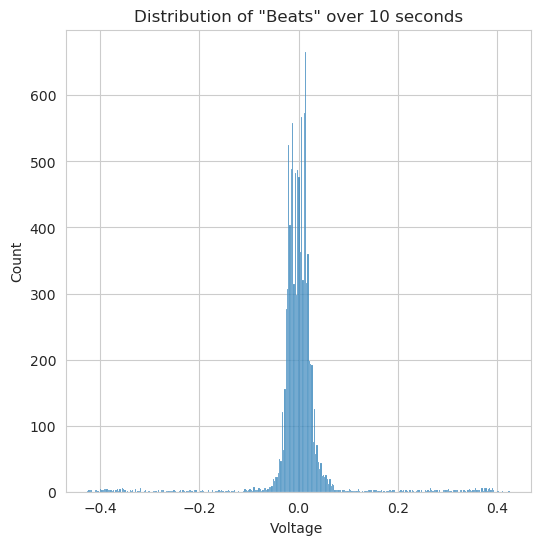

In [15]:
# Create plot features
plt.figure(figsize=(6, 6))

sns.set_style(style = 'whitegrid')
sns.despine()


sns.histplot(data=df, x = "Channel 3")
# Customize the plot
plt.xlabel('Voltage ')
plt.ylabel('Count')
plt.title('Distribution of "Beats" over 10 seconds')
plt.savefig("Distribution_of_Beats_over_10_seconds.png", dpi=300)
plt.show()
 

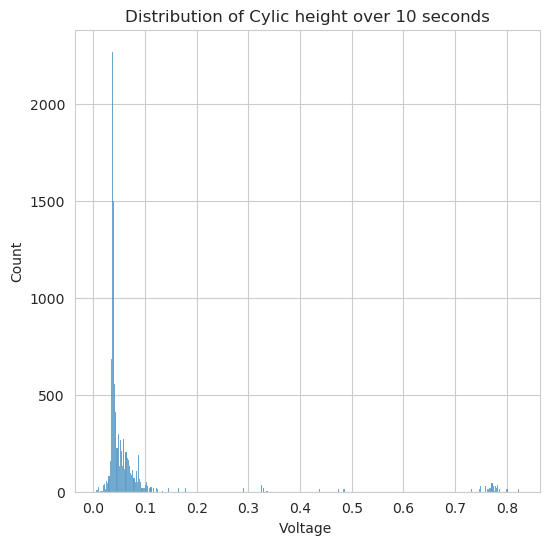

In [16]:
# Create plot features
plt.figure(figsize=(6, 6))

sns.set_style(style = 'whitegrid')
sns.despine()


sns.histplot(data=df, x = "Channel 2")
# Customize the plot
plt.xlabel('Voltage ')
plt.ylabel('Count')
plt.title('Distribution of Cylic height over 10 seconds')
plt.savefig("Distribution_of_Cyclic_height_10_seconds.png", dpi=300)
plt.show()

In [ ]:
# Create plot features
plt.figure(figsize=(6, 6))

sns.set_style(style = 'whitegrid')
sns.despine()


sns.histplot(data=df, x = "Channel 1")
# Customize the plot
plt.xlabel('V/s ')
plt.ylabel('Count')
plt.title('Distribution of Change in voltage over 10 seconds')
plt.savefig("Distribution_of_Changeinvoltage_10_seconds.png", dpi=300)
plt.show()

In [18]:
# Calculating # of samples per second
Number_of_samples_in1second = time <= 1.0

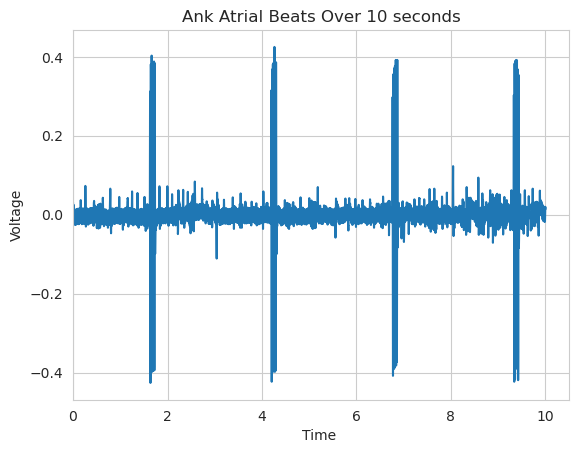

In [19]:
sns.lineplot(data=df, x = "Time" , y = "Channel 3")

# Customize the plot
plt.xlabel('Time ')
plt.ylabel('Voltage')
plt.title('Ank Atrial Beats Over 10 seconds')
plt.xlim(0, 10.5)
plt.savefig("AnkAtrialBeats10sc.png", dpi=300)
plt.show()

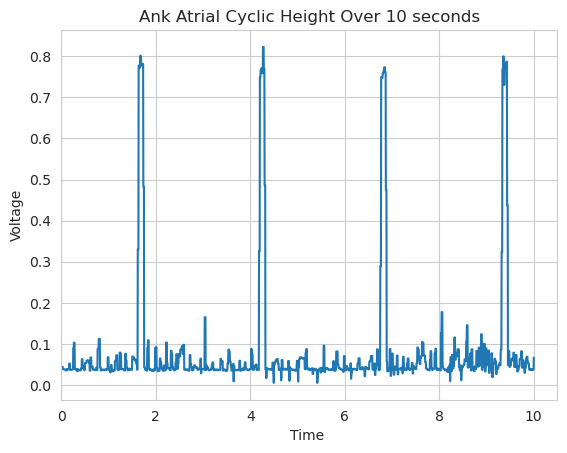

In [20]:
sns.lineplot(data=df, x = "Time" , y = "Channel 2")

# Customize the plot
plt.xlabel('Time ')
plt.ylabel('Voltage')
plt.title('Ank Atrial Cyclic Height Over 10 seconds')
plt.xlim(0, 10.5)
plt.savefig("AnkAtrialCH10sc.png", dpi=300)
plt.show()

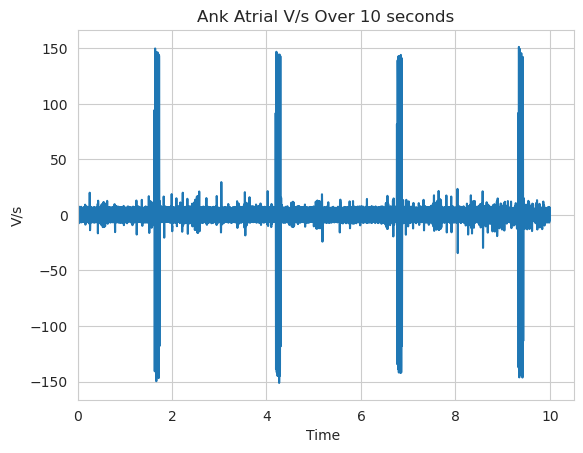

In [21]:
sns.lineplot(data=df, x = "Time" , y = "Channel 1")

# Customize the plot
plt.xlabel('Time ')
plt.ylabel('V/s')
plt.title('Ank Atrial V/s Over 10 seconds')
plt.xlim(0, 10.5)
plt.savefig("AnkAtrialV_S10sc.png", dpi=300)
plt.show()

In [63]:
print(df.head())

    Time  Channel 1  Channel 2  Channel 3
0  0.000      -7.66        NaN      0.031
1  0.001      -7.66        NaN      0.023
2  0.002      -7.19        NaN      0.015
3  0.003      -6.41        NaN      0.009
4  0.004      -4.69        NaN      0.003


In [64]:
# Making a dataframe for each second hard way
# f_df = df.iloc[0:1001]
# s_df = df.iloc[1001:2001]
# t_df = df.iloc[2001:3001]
# f_df = df.iloc[3001:4001]

In [65]:
# Chunking my data
chunk_size = 1001  # Size of each smaller chunk
num_chunks = 10  # Number of chunks you want

# Split the dataframe into smaller dataframes
dfs = [df.iloc[i*chunk_size : (i+1)*chunk_size] for i in range(num_chunks)]

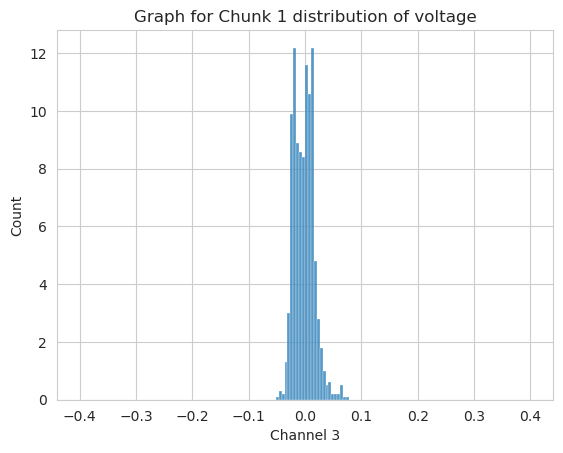

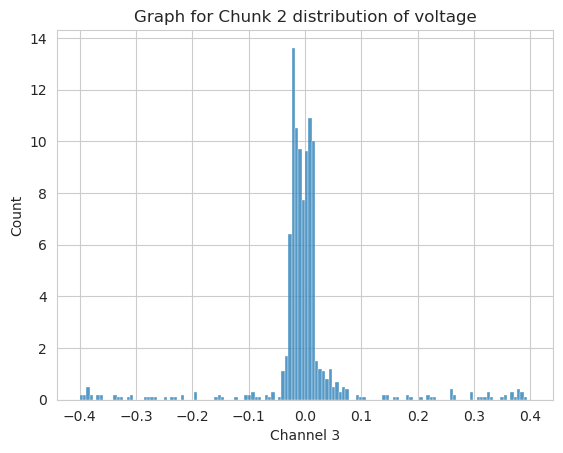

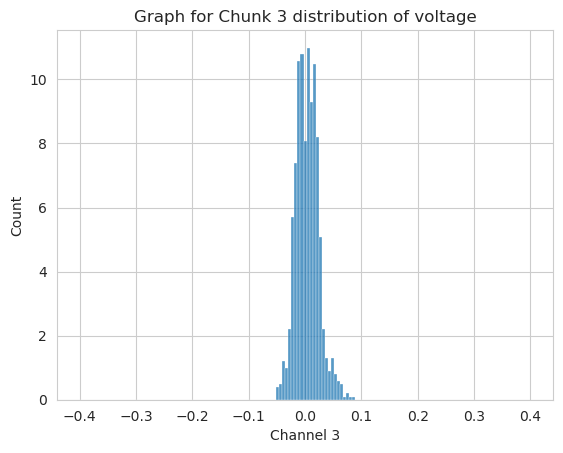

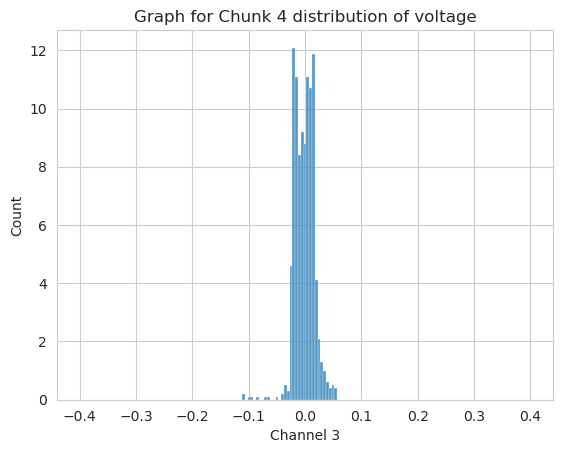

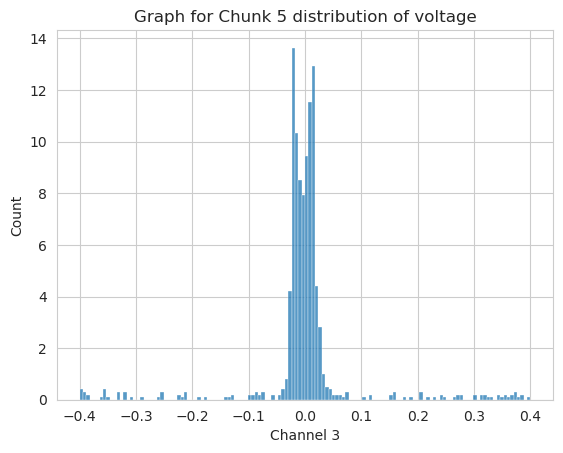

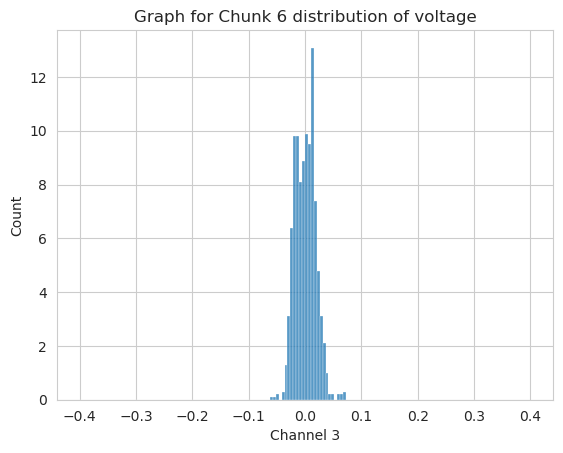

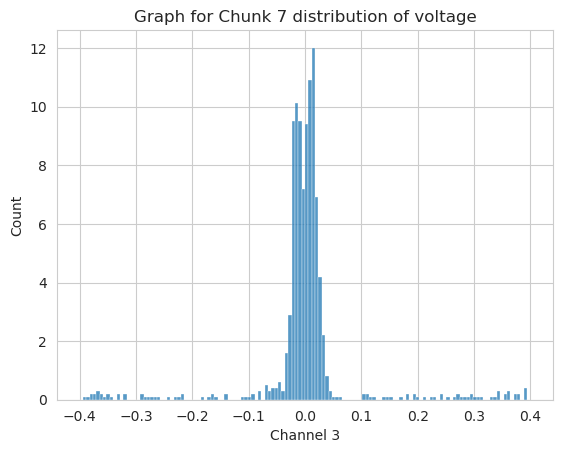

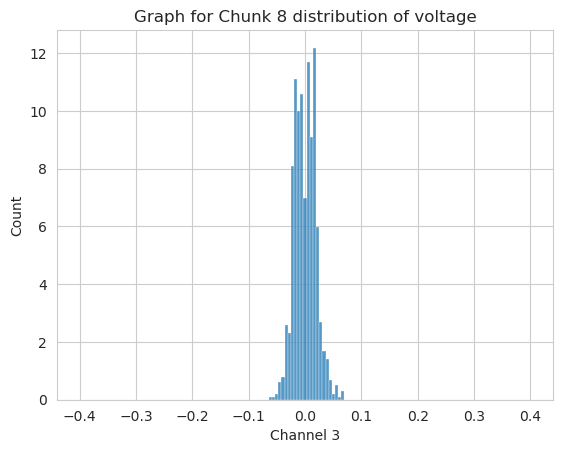

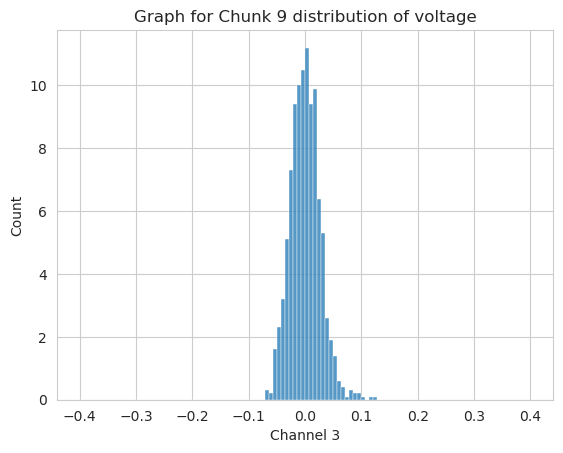

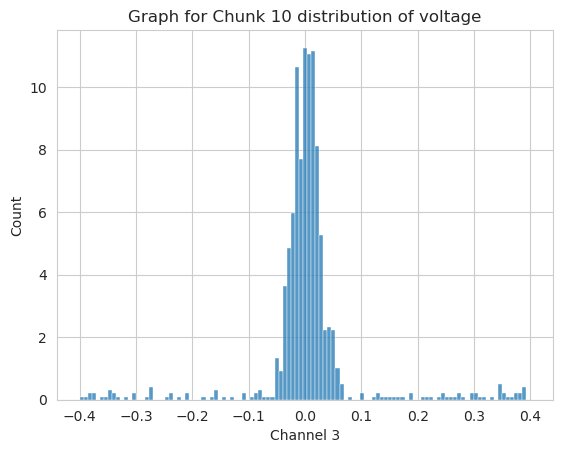

In [78]:
# Now we iterate over the list 'dfs' to generate individual plots
for i, chunk_df in enumerate(dfs):
    # Create a new figure for each plot
    plt.figure()
    
    # Seaborn example plot: plotting all columns (you can customize this based on your data)
    sns.histplot(data=chunk_df,  x='Channel 3', stat = 'percent', binrange = (-0.4 , 0.4))  # Modify based on your columns
    
    # Add titles or labels specific to each chunk
    plt.title(f"Graph for Chunk {i+1} distribution of voltage")
    plt.xlabel("Channel 3")  # Replace with actual column name if necessary
    plt.ylabel("Count")  # Replace with actual column name if necessary
    
    
    # Show the plot
    plt.show()

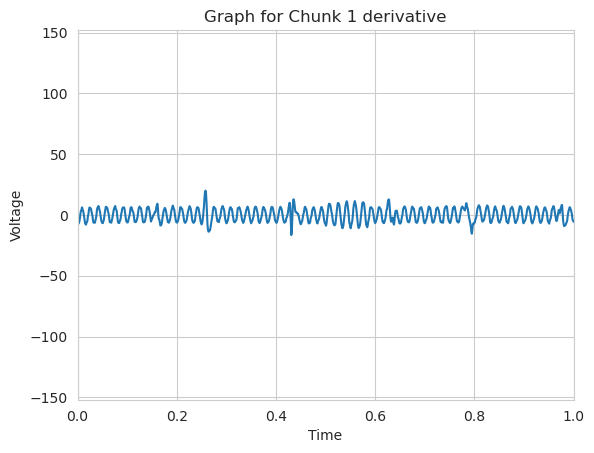

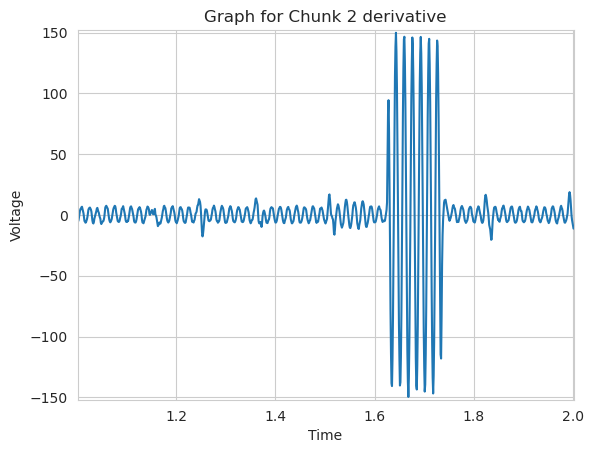

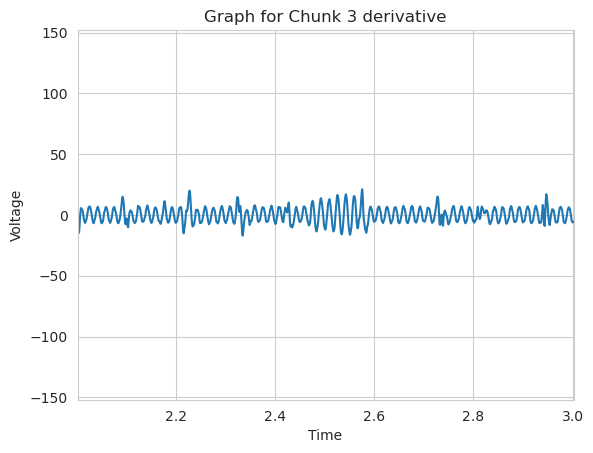

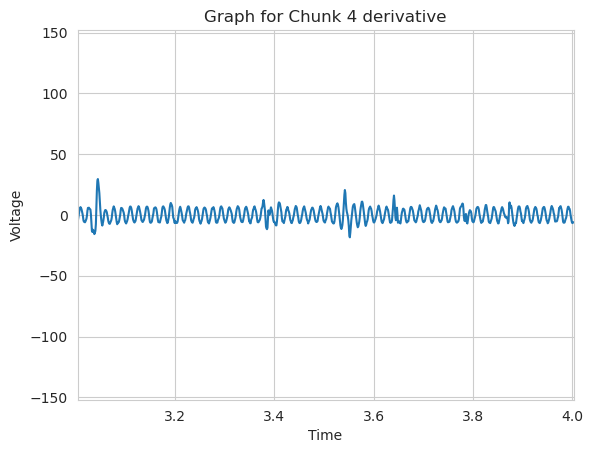

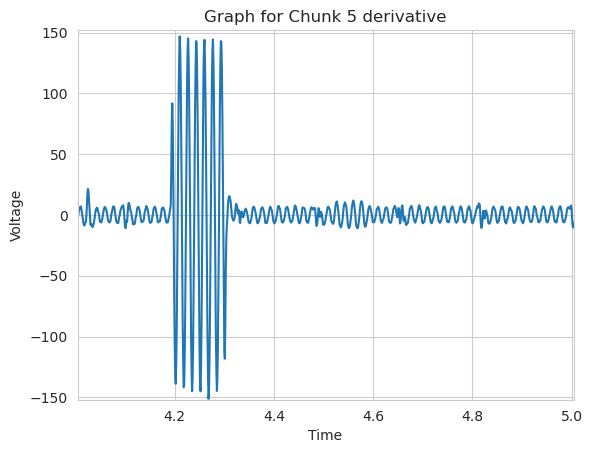

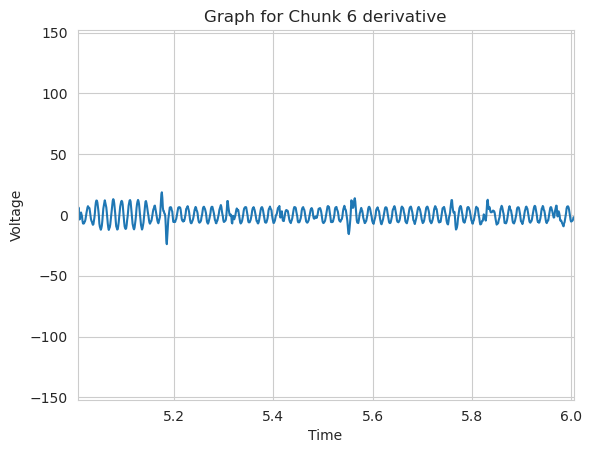

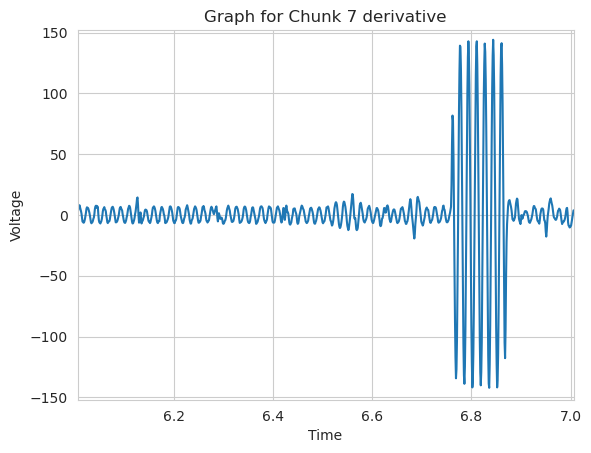

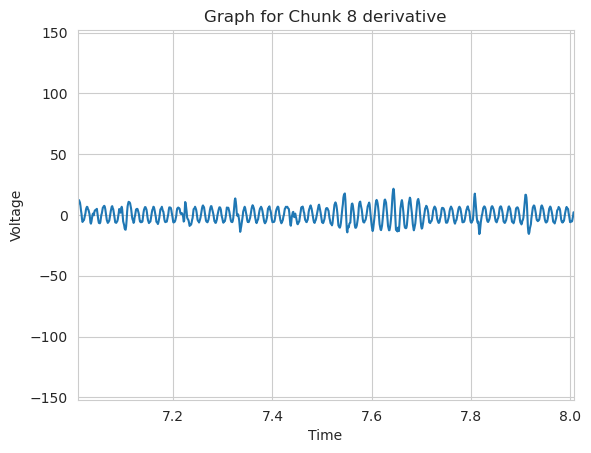

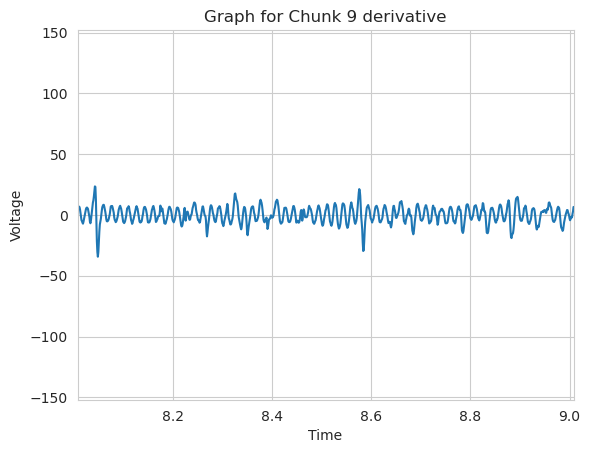

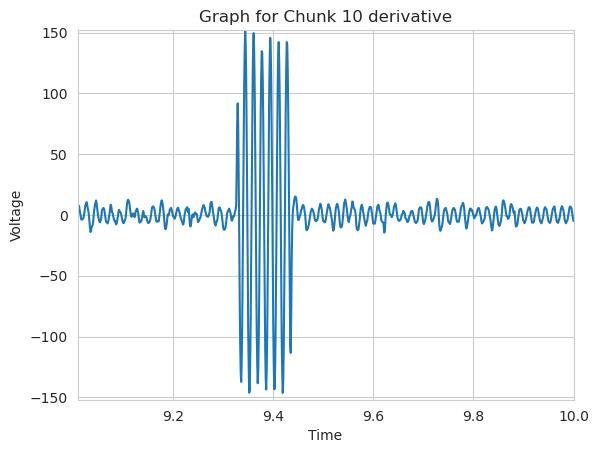

In [77]:
# Now we iterate over the list 'dfs' to generate individual plots
for i, chunk_df in enumerate(dfs):
    # Create a new figure for each plot
    plt.figure()
    
    # Seaborn example plot: plotting all columns (you can customize this based on your data)
    sns.lineplot(data=chunk_df, x = "Time" , y = "Channel 1")
    
    # Add titles or labels specific to each chunk
    plt.title(f"Graph for Chunk {i+1} derivative")
    plt.xlabel("Time")  # Replace with actual column name if necessary
    plt.ylabel("Voltage")  # Replace with actual column name if necessary
    
    
    # Adjust x-axis limits to fit the chunk's time range
    # 'Time' is in seconds and data is chunked by 1 second
    plt.xlim(chunk_df["Time"].min(), chunk_df["Time"].max())
    plt.ylim(-152,152)
    # Show the plot
    plt.show()

In [26]:
Number_of_samples_above = df['Channel 1'] > 50

In [27]:
print(Number_of_samples_above.sum())

168


In [29]:
Number_of_samples_below = df['Channel 1'] < -50

In [30]:
print(Number_of_samples_below.sum())

169


In [7]:
above_below = Number_of_samples_below + Number_of_samples_above

In [8]:
above_below_sum = above_below.sum()

In [9]:
print(above_below_sum)

337


In [75]:
print(df['Channel 1'].count())

10001


In [32]:
337/10001

0.0336966303369663